In [12]:
#imports and seed

import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

# Make repo src/ importable
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))) + "/src")

# Ring-attractor imports
from ring_attractor.network import RingAttractor, CosineKernelInitStrategy, RingAttractorSimulator
from ring_attractor.nonlinearity import ReLUNonlinearity
from ring_attractor.spiking import SpikeGenerator, SpikeGeneratorSimulator, SpikeProcessor

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

print("Imports successful. Seed set to", SEED)

Imports successful. Seed set to 42


In [21]:
#global parameters from 02_spike_collection

NETWORK_SIZE = 100
J0, J1 = -2.0, 4.0 # We might want to tweak this

SIMULATION_TIMESTEP = 0.01 # Might want to change this to 0.1?
TAU = 100.0
SIGMA = 0.1 # Noise

CUE_THETA_TARGET = np.pi / 2
CUE_AMPLITUDE = 2.0

T_CUE = 200   # steps with cue on  (bump formation)
T_FREE = 800  # steps with cue off (free diffusion)
T_TOTAL = T_CUE + T_FREE

# The rate scale multiplies the dimensionless attractor rates before Poisson sampling.
# Increase if the raster looks too sparse, decrease if fraction-2+ is large.
# Target -- most bins 0 or 1, peak neurons firing ~10-30% of steps.
RATE_SCALE = 100.0
BIN_FACTOR = 100 # 1ms (100 * SIMULATION_TIMESTEP)
WINDOW_BINS = 3

SEED = 42

#New dataset-level parameters for multi-trial generation
N_TRIALS = 40
theta_targets = np.linspace(0, 2 * np.pi, N_TRIALS, endpoint=False)

print("N_TRIALS:", N_TRIALS)
print("theta_targets shape:", theta_targets.shape)
print("first 5 theta targets:", theta_targets[:5])

N_TRIALS: 40
theta_targets shape: (40,)
first 5 theta targets: [0.         0.15707963 0.31415927 0.4712389  0.62831853]


In [22]:
#helper to build the teacher attractor

def make_teacher_system(seed=SEED):
    """
    Build the same teacher system as in 02_spike_collection:
    attractor + simulator + spike generator + spike simulator.
    """
    rng = np.random.default_rng(seed)

    attractor = RingAttractor(
        NETWORK_SIZE,
        CosineKernelInitStrategy(j0=J0, j1=J1),
        ReLUNonlinearity(),
        rng,
    )

    simulator = RingAttractorSimulator(
        attractor,
        SIMULATION_TIMESTEP,
        tau=TAU,
        sigma=SIGMA,
        rng=rng,
    )

    spike_gen = SpikeGenerator(
        dt=SIMULATION_TIMESTEP,
        rate_scale=RATE_SCALE,
        rng=rng
    )

    sgs = SpikeGeneratorSimulator(spike_gen, simulator)

    return attractor, simulator, spike_gen, sgs, rng

In [23]:
#build cue_schedule

def make_cue_schedule(attractor, theta_target):
    """
    Build the cue schedule exactly like in 02_spike_collection,
    but for any chosen theta_target.
    """
    cue_on = CUE_AMPLITUDE * np.cos(attractor.neuron_angles - theta_target)

    cue_schedule = np.zeros((T_TOTAL, NETWORK_SIZE))
    cue_schedule[:T_CUE] = cue_on

    return cue_schedule

In [24]:
#run the simulation

def generate_teacher_trial(theta_target, seed=SEED):
    """
    Generate one trial using the exact logic from 02_spike_collection.
    """
    attractor, simulator, spike_gen, sgs, rng = make_teacher_system(seed=seed)

    cue_schedule = make_cue_schedule(attractor, theta_target)

    sgs.perform_steps(cue_schedule)

    spikes_int = sgs.spikes
    rates_true = sgs.neuron_rates
    theta_hat = sgs.decoded_angle
    confidence = sgs.decoding_confidence

    return {
        "cue_schedule": cue_schedule,
        "spikes_int": spikes_int,
        "rates_true": rates_true,
        "theta_hat": theta_hat,
        "confidence": confidence,
        "theta_target": theta_target,
    }

In [25]:
#Sanity check for one generated trial

trial0 = generate_teacher_trial(theta_targets[0], seed=SEED)

cue_schedule = trial0["cue_schedule"]
spikes_int   = trial0["spikes_int"]
rates_true   = trial0["rates_true"]
theta_hat    = trial0["theta_hat"]
confidence   = trial0["confidence"]

print("===== SHAPES =====")
print("cue_schedule :", cue_schedule.shape)
print("spikes_int   :", spikes_int.shape)
print("rates_true   :", rates_true.shape)
print("theta_hat    :", theta_hat.shape)
print("confidence   :", confidence.shape)

print("\n===== BASIC STATS =====")
print("spikes mean  :", spikes_int.mean())
print("spikes max   :", spikes_int.max())
print("rates mean   :", rates_true.mean())
print("rates max    :", rates_true.max())

print("\n===== ANGLE RANGE =====")
print("theta_hat min:", theta_hat.min())
print("theta_hat max:", theta_hat.max())

===== SHAPES =====
cue_schedule : (1000, 100)
spikes_int   : (1000, 100)
rates_true   : (1000, 100)
theta_hat    : (1000,)
confidence   : (1000,)

===== BASIC STATS =====
spikes mean  : 0.01286
spikes max   : 2
rates mean   : 0.011416289
rates max    : 0.048492435

===== ANGLE RANGE =====
theta_hat min: 0.05733776434981459
theta_hat max: 2.2462275323642125


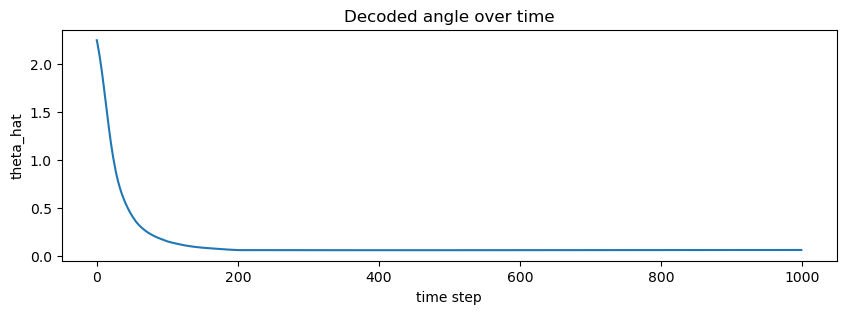

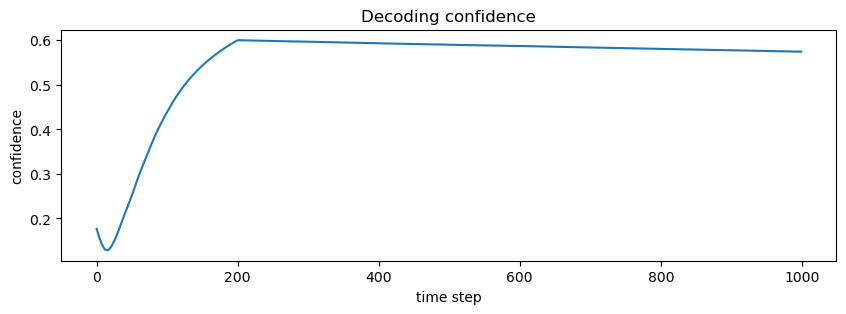

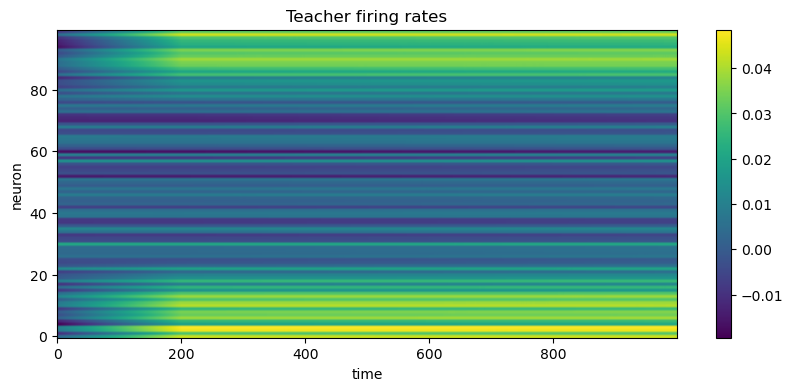

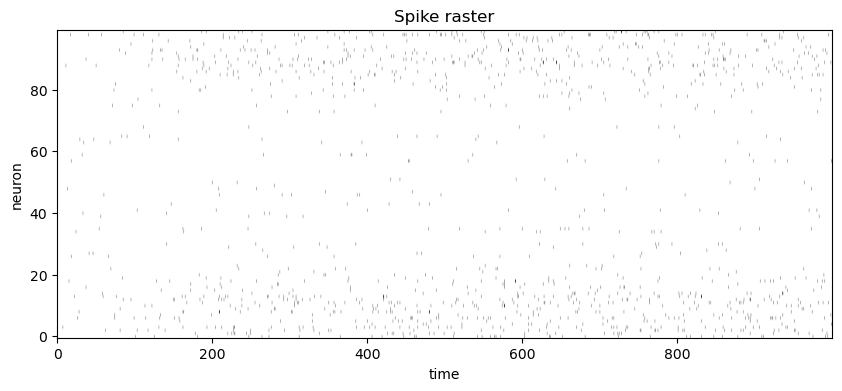

In [26]:
# Plot decoded angle
plt.figure(figsize=(10,3))
plt.plot(theta_hat)
plt.title("Decoded angle over time")
plt.xlabel("time step")
plt.ylabel("theta_hat")
plt.show()

# ---- Plot confidence ----
plt.figure(figsize=(10,3))
plt.plot(confidence)
plt.title("Decoding confidence")
plt.xlabel("time step")
plt.ylabel("confidence")
plt.show()

# ---- Plot teacher rates heatmap ----
plt.figure(figsize=(10,4))
plt.imshow(rates_true.T, aspect="auto", origin="lower")
plt.title("Teacher firing rates")
plt.xlabel("time")
plt.ylabel("neuron")
plt.colorbar()
plt.show()

# ---- Plot spike raster ----
plt.figure(figsize=(10,4))
plt.imshow(spikes_int.T, aspect="auto", origin="lower", cmap="Greys")
plt.title("Spike raster")
plt.xlabel("time")
plt.ylabel("neuron")
plt.show()

In [27]:
#smooths the binned spikes

def smooth_causal_boxcar(signal: np.ndarray, window: int) -> np.ndarray:
    """
    Causal boxcar smoothing along axis 0.
    output[t] = mean(input[t-window+1 : t+1])
    """
    kernel = np.ones(window) / window
    return np.apply_along_axis(
        lambda col: np.convolve(col, kernel, mode="full")[: len(col)],
        axis=0,
        arr=signal.astype(float),
    )

In [28]:
#processing one trial into binned/smoothed outputs

def process_trial_outputs(spikes_int, rates_true, theta_hat, theta_target):
    """
    Match the spike-processing stage from 02_spike_collection.
    """
    processor = SpikeProcessor(dt=SIMULATION_TIMESTEP, bin_factor=BIN_FACTOR)

    spikes_bin = processor.bin_spikes(spikes_int)   # (T//BIN_FACTOR, NETWORK_SIZE)

    dt_bin = SIMULATION_TIMESTEP * BIN_FACTOR
    T_BIN = spikes_bin.shape[0]

    rates_smooth = smooth_causal_boxcar(spikes_bin, WINDOW_BINS) / dt_bin

    rates_true_bin = rates_true[: T_BIN * BIN_FACTOR].reshape(
        T_BIN, BIN_FACTOR, NETWORK_SIZE
    ).mean(axis=1)

    theta_hat_bin = theta_hat[: T_BIN * BIN_FACTOR : BIN_FACTOR]

    dataset = {
        "spikes_int": spikes_int,
        "spikes_bin": spikes_bin,
        "rates_smooth": rates_smooth,
        "rates_true": rates_true,
        "rates_true_bin": rates_true_bin,
        "theta_hat": theta_hat,
        "theta_hat_bin": theta_hat_bin,
        "params": {
            "N": NETWORK_SIZE,
            "J0": J0,
            "J1": J1,
            "dt_int": SIMULATION_TIMESTEP,
            "dt_bin": dt_bin,
            "bin_factor": BIN_FACTOR,
            "smoothing_window_bins": WINDOW_BINS,
            "tau": TAU,
            "sigma": SIGMA,
            "rate_scale": RATE_SCALE,
            "T_cue": T_CUE,
            "T_free": T_FREE,
            "theta_target": float(theta_target),
            "cue_amplitude": CUE_AMPLITUDE,
            "seed": SEED,
        },
    }

    return dataset

In [29]:
#updated "genrate_teacher_trial"

def generate_teacher_trial(theta_target, seed=SEED):
    """
    Generate one teacher trial using the exact logic from 02_spike_collection,
    then add binned/smoothed outputs.
    """
    attractor, simulator, spike_gen, sgs, rng = make_teacher_system(seed=seed)

    cue_schedule = make_cue_schedule(attractor, theta_target)

    sgs.perform_steps(cue_schedule)

    spikes_int = sgs.spikes
    rates_true = sgs.neuron_rates
    theta_hat = sgs.decoded_angle
    confidence = sgs.decoding_confidence

    processed = process_trial_outputs(
        spikes_int=spikes_int,
        rates_true=rates_true,
        theta_hat=theta_hat,
        theta_target=theta_target,
    )

    processed["cue_schedule"] = cue_schedule
    processed["confidence"] = confidence

    return processed


In [30]:
# sanity check for the processed outputs

trial0 = generate_teacher_trial(theta_targets[0], seed=SEED)

print(f"spikes_int    : {trial0['spikes_int'].shape}")
print(f"spikes_bin    : {trial0['spikes_bin'].shape}   (BIN_FACTOR={BIN_FACTOR})")
print(f"rates_smooth  : {trial0['rates_smooth'].shape}")
print(f"rates_true    : {trial0['rates_true'].shape}")
print(f"rates_true_bin: {trial0['rates_true_bin'].shape}")
print(f"theta_hat     : {trial0['theta_hat'].shape}")
print(f"theta_hat_bin : {trial0['theta_hat_bin'].shape}")
print(f"confidence    : {trial0['confidence'].shape}")
print(f"cue_schedule  : {trial0['cue_schedule'].shape}")

spikes_int    : (1000, 100)
spikes_bin    : (10, 100)   (BIN_FACTOR=100)
rates_smooth  : (10, 100)
rates_true    : (1000, 100)
rates_true_bin: (10, 100)
theta_hat     : (1000,)
theta_hat_bin : (10,)
confidence    : (1000,)
cue_schedule  : (1000, 100)


In [32]:
#generate all trials

all_trials = []

for i, theta in enumerate(theta_targets):
    trial = generate_teacher_trial(theta_target=theta, seed=SEED + i)
    all_trials.append(trial)

print("Generated", len(all_trials), "trials")
print("Example trial keys:", all_trials[0].keys())

Generated 40 trials
Example trial keys: dict_keys(['spikes_int', 'spikes_bin', 'rates_smooth', 'rates_true', 'rates_true_bin', 'theta_hat', 'theta_hat_bin', 'params', 'cue_schedule', 'confidence'])


In [33]:
#stack shared arrays

X_cue = np.stack([trial["cue_schedule"] for trial in all_trials], axis=0)         # [n_trials, T, N]
X_spikes = np.stack([trial["spikes_int"] for trial in all_trials], axis=0)        # [n_trials, T, N]

Y_rates = np.stack([trial["rates_true"] for trial in all_trials], axis=0)         # [n_trials, T, N]
Y_rates_bin = np.stack([trial["rates_true_bin"] for trial in all_trials], axis=0) # [n_trials, T_bin, N]
Y_rates_smooth = np.stack([trial["rates_smooth"] for trial in all_trials], axis=0)# [n_trials, T_bin, N]

Y_theta = np.stack([trial["theta_hat"] for trial in all_trials], axis=0)          # [n_trials, T]
Y_theta_bin = np.stack([trial["theta_hat_bin"] for trial in all_trials], axis=0)  # [n_trials, T_bin]

confidence_all = np.stack([trial["confidence"] for trial in all_trials], axis=0)  # [n_trials, T]
theta_target_per_trial = np.array([trial["params"]["theta_target"] for trial in all_trials])

print("X_cue:", X_cue.shape)
print("X_spikes:", X_spikes.shape)
print("Y_rates:", Y_rates.shape)
print("Y_rates_bin:", Y_rates_bin.shape)
print("Y_rates_smooth:", Y_rates_smooth.shape)
print("Y_theta:", Y_theta.shape)
print("Y_theta_bin:", Y_theta_bin.shape)
print("confidence_all:", confidence_all.shape)
print("theta_target_per_trial:", theta_target_per_trial.shape)

X_cue: (40, 1000, 100)
X_spikes: (40, 1000, 100)
Y_rates: (40, 1000, 100)
Y_rates_bin: (40, 10, 100)
Y_rates_smooth: (40, 10, 100)
Y_theta: (40, 1000)
Y_theta_bin: (40, 10)
confidence_all: (40, 1000)
theta_target_per_trial: (40,)


In [35]:
#fixed train/test splits

rng_split = np.random.default_rng(SEED)

n_trials = len(all_trials)
perm = rng_split.permutation(n_trials)

n_train = int(0.8 * n_trials)
train_idx = perm[:n_train]
test_idx = perm[n_train:]

print("n_train:", len(train_idx))
print("n_test :", len(test_idx))
print("train_idx:", train_idx)
print("test_idx :", test_idx)

n_train: 32
n_test : 8
train_idx: [32  7 39 18  4 37 16  5 25 28 21 20 35 24 10 27 31 30 26  6 29 11 23  9
 36 22 19  3  0 15 17 34]
test_idx : [12 14 38  2 33  1 13  8]


In [36]:
#observed neuron mask

rng_mask = np.random.default_rng(SEED)

def make_observed_idx(n_neurons, frac, rng):
    n_obs = max(1, int(round(frac * n_neurons)))
    idx = rng.choice(n_neurons, size=n_obs, replace=False)
    return np.sort(idx)

obs_idx_100 = make_observed_idx(NETWORK_SIZE, 1.00, rng_mask)
obs_idx_50  = make_observed_idx(NETWORK_SIZE, 0.50, rng_mask)
obs_idx_25  = make_observed_idx(NETWORK_SIZE, 0.25, rng_mask)
obs_idx_10  = make_observed_idx(NETWORK_SIZE, 0.10, rng_mask)

print("Observed neuron counts:",
      len(obs_idx_100), len(obs_idx_50), len(obs_idx_25), len(obs_idx_10))

Observed neuron counts: 100 50 25 10


In [37]:
#observed input versions

X_rates_obs_100 = Y_rates[:, :, obs_idx_100]
X_rates_obs_50  = Y_rates[:, :, obs_idx_50]
X_rates_obs_25  = Y_rates[:, :, obs_idx_25]
X_rates_obs_10  = Y_rates[:, :, obs_idx_10]

print("X_rates_obs_100:", X_rates_obs_100.shape)
print("X_rates_obs_50 :", X_rates_obs_50.shape)
print("X_rates_obs_25 :", X_rates_obs_25.shape)
print("X_rates_obs_10 :", X_rates_obs_10.shape)

X_rates_obs_100: (40, 1000, 100)
X_rates_obs_50 : (40, 1000, 50)
X_rates_obs_25 : (40, 1000, 25)
X_rates_obs_10 : (40, 1000, 10)


In [38]:
#save the shared dataset

np.savez(
    "shared_ring_dataset.npz",
    X_cue=X_cue,
    X_spikes=X_spikes,
    Y_rates=Y_rates,
    Y_rates_bin=Y_rates_bin,
    Y_rates_smooth=Y_rates_smooth,
    Y_theta=Y_theta,
    Y_theta_bin=Y_theta_bin,
    confidence_all=confidence_all,
    theta_target_per_trial=theta_target_per_trial,
    train_idx=train_idx,
    test_idx=test_idx,
    obs_idx_100=obs_idx_100,
    obs_idx_50=obs_idx_50,
    obs_idx_25=obs_idx_25,
    obs_idx_10=obs_idx_10,
    X_rates_obs_100=X_rates_obs_100,
    X_rates_obs_50=X_rates_obs_50,
    X_rates_obs_25=X_rates_obs_25,
    X_rates_obs_10=X_rates_obs_10,
)
print("Saved shared_ring_dataset.npz")

Saved shared_ring_dataset.npz


In [39]:
#load check

data = np.load("shared_ring_dataset.npz")

print(data.files)
print("Loaded X_rates_obs_50:", data["X_rates_obs_50"].shape)
print("Loaded Y_rates:", data["Y_rates"].shape)
print("Loaded Y_theta:", data["Y_theta"].shape)

['X_cue', 'X_spikes', 'Y_rates', 'Y_rates_bin', 'Y_rates_smooth', 'Y_theta', 'Y_theta_bin', 'confidence_all', 'theta_target_per_trial', 'train_idx', 'test_idx', 'obs_idx_100', 'obs_idx_50', 'obs_idx_25', 'obs_idx_10', 'X_rates_obs_100', 'X_rates_obs_50', 'X_rates_obs_25', 'X_rates_obs_10']
Loaded X_rates_obs_50: (40, 1000, 50)
Loaded Y_rates: (40, 1000, 100)
Loaded Y_theta: (40, 1000)
